In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries Imported")

Libraries Imported


In [ ]:
data = pd.read_csv("diamonds.csv")

print("Dataset Reading Complete")

Dataset Reading Complete


In [ ]:
data.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
data.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
17853,17854,1.16,Ideal,G,VS2,62.3,57.0,7203,6.72,6.66,4.17
17854,17855,1.47,Premium,J,VS2,61.5,58.0,7203,7.31,7.29,4.49
17855,17856,1.16,Premium,G,VS2,59.9,60.0,7203,6.88,6.85,4.11
17856,17857,1.00,Very Good,F,VS1,60.4,59.0,7204,6.40,6.51,3.90
17857,17858,1.33,Premium,H,SI1,61.1,61.0,7204,7.05,7.00,NaN


In [ ]:
# Fill missing value with median
data['z'] = data['z'].fillna(data['z'].median())

# Check if missing values are removed
print(data.isnull().sum())

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [ ]:
data.shape

(17858, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17858 entries, 0 to 17857
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  17858 non-null  int64  
 1   carat       17858 non-null  float64
 2   cut         17858 non-null  object 
 3   color       17858 non-null  object 
 4   clarity     17858 non-null  object 
 5   depth       17858 non-null  float64
 6   table       17858 non-null  float64
 7   price       17858 non-null  int64  
 8   x           17858 non-null  float64
 9   y           17858 non-null  float64
 10  z           17858 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 1.5+ MB


In [ ]:
data.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,17858.000000,17858.000000,17858.000000,17858.000000,17858.000000,17858.000000,17858.000000,17858.000000
mean,8929.500000,0.930882,61.833744,57.781504,4210.086628,6.171439,6.170635,3.813928
std,5155.304889,0.278732,1.578816,2.244017,1675.393211,0.736743,0.724990,0.462983
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,4465.250000,0.800000,61.000000,56.000000,3297.000000,5.940000,5.950000,3.670000
50%,8929.500000,1.000000,61.900000,58.000000,4318.000000,6.360000,6.360000,3.940000
75%,13393.750000,1.070000,62.700000,59.000000,5367.750000,6.600000,6.590000,4.070000
max,17858.000000,3.000000,71.800000,70.000000,7204.000000,9.230000,9.100000,5.770000


In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [ ]:
data['cut'].value_counts()

,count
cut,
Ideal,5692
Premium,4895
Very Good,4438
Good,2081
Fair,752


In [ ]:
data['color'].value_counts()

,count
color,
G,3357
H,3309
F,3062
E,2872
D,2149
I,1999
J,1110


In [ ]:
data['clarity'].value_counts()

,count
clarity,
SI1,5359
SI2,4635
VS2,3786
VS1,2198
VVS2,784
VVS1,526
I1,399
IF,171


In [ ]:
data = pd.get_dummies(
    data,
    columns=['cut','color','clarity'],
    drop_first=True,
    dtype=int
)

data.columns

Index(['Unnamed: 0', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z',
       'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_E',
       'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_IF',
       'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2',
       'clarity_VVS1', 'clarity_VVS2'],
      dtype='object')

In [ ]:
X = data.drop(['Unnamed: 0','price'], axis=1)

print("Feature Matrix Created")

Feature Matrix Created


In [ ]:
Y = data['price']

print("Target Variable Created")

Target Variable Created


In [ ]:
X.head()

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,3.89,3.84,2.31,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,4.05,4.07,2.31,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,4.20,4.23,2.63,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,4.34,4.35,2.75,1,0,0,0,...,0,0,1,0,0,1,0,0,0,0


In [ ]:
Y.head()

,price
0,326
1,326
2,327
3,334
4,335


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=100
)

In [ ]:
model = LinearRegression()

model.fit(X_train, Y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
Y_train_pred = model.predict(X_train)

Y_test_pred = model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [ ]:
mae = mean_absolute_error(Y_train,Y_train_pred)
mse = mean_squared_error(Y_train,Y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_train,Y_train_pred)

print("Training Results")
print("MAE :",mae)
print("MSE :",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

Training Results
MAE : 435.89218752573055
MSE : 320562.0797394823
RMSE: 566.1820199719189
R2 Score: 0.8854763786967217


In [ ]:
mae = mean_absolute_error(Y_test,Y_test_pred)
mse = mean_squared_error(Y_test,Y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,Y_test_pred)

print("Testing Results")
print("MAE :",mae)
print("MSE :",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

Testing Results
MAE : 436.6135003020325
MSE : 334040.31935529975
RMSE: 577.962212739985
R2 Score: 0.8822639308531456


In [ ]:
print("Coefficients:",model.coef_)

print("Intercept:",model.intercept_)

Coefficients: [ 5.58972974e+03 -2.49328980e+00 -8.09989146e+00 -3.85925205e+02
  6.83118044e+02  9.09812837e+01  4.51816422e+02  6.87488784e+02
  5.38053103e+02  5.65950667e+02 -1.81472158e+02 -2.29048720e+02
 -2.97904216e+02 -5.96405740e+02 -1.00761927e+03 -1.54406186e+03
  3.39382066e+03  2.44530783e+03  1.79183606e+03  3.00752514e+03
  2.95558298e+03  3.27148824e+03  3.13641239e+03]
Intercept: -5131.079216342249


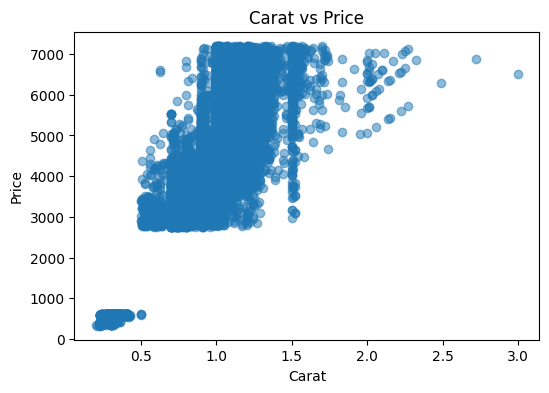

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(data['carat'], data['price'], alpha=0.5)
plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")
plt.show()